### Yoonjae Lee

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

img = np.array(Image.open(Path("Images") / "Group_6.png").convert("RGB"))
H, W = img.shape[0], img.shape[1]
ROWS, COLS = 6, 9


In [2]:
def split_lengths(total: int, n: int) -> list:
    base, rem = total // n, total % n
    return [base + (1 if i < rem else 0) for i in range(n)]


row_heights = split_lengths(H, ROWS)
col_widths = split_lengths(W, COLS)
y_edges = [0] + list(np.cumsum(row_heights))
x_edges = [0] + list(np.cumsum(col_widths))


In [3]:
def cell(r: int, c: int) -> np.ndarray:
    return img[y_edges[r] : y_edges[r + 1], x_edges[c] : x_edges[c + 1]]


def strip_border(patch: np.ndarray, margin: int) -> np.ndarray:
    if margin <= 0:
        return patch
    h, w = patch.shape[0], patch.shape[1]
    if h <= 2 * margin or w <= 2 * margin:
        return patch
    return patch[margin:-margin, margin:-margin]


def center_crop(patch: np.ndarray, out_h: int, out_w: int) -> np.ndarray:
    h, w = patch.shape[0], patch.shape[1]
    y0 = max(0, (h - out_h) // 2)
    x0 = max(0, (w - out_w) // 2)
    return patch[y0 : y0 + out_h, x0 : x0 + out_w]


def letter(r: int, c: int, margin: int, out_h: int, out_w: int) -> np.ndarray:
    p = strip_border(cell(r, c), margin)
    return center_crop(p, out_h, out_w)


In [4]:
FIRST_COORDS = [(0, 7), (1, 1), (1, 1), (0, 2), (3, 8), (1, 2), (5, 2)]
LAST_COORDS = [(5, 1), (5, 2), (5, 2)]

MARGIN = 6
test_patches = [strip_border(cell(r, c), MARGIN) for r, c in set(FIRST_COORDS + LAST_COORDS)]
OUT_H = min(p.shape[0] for p in test_patches)
OUT_W = min(p.shape[1] for p in test_patches)

first_letters = [letter(r, c, MARGIN, OUT_H, OUT_W) for r, c in FIRST_COORDS]
last_letters = [letter(r, c, MARGIN, OUT_H, OUT_W) for r, c in LAST_COORDS]


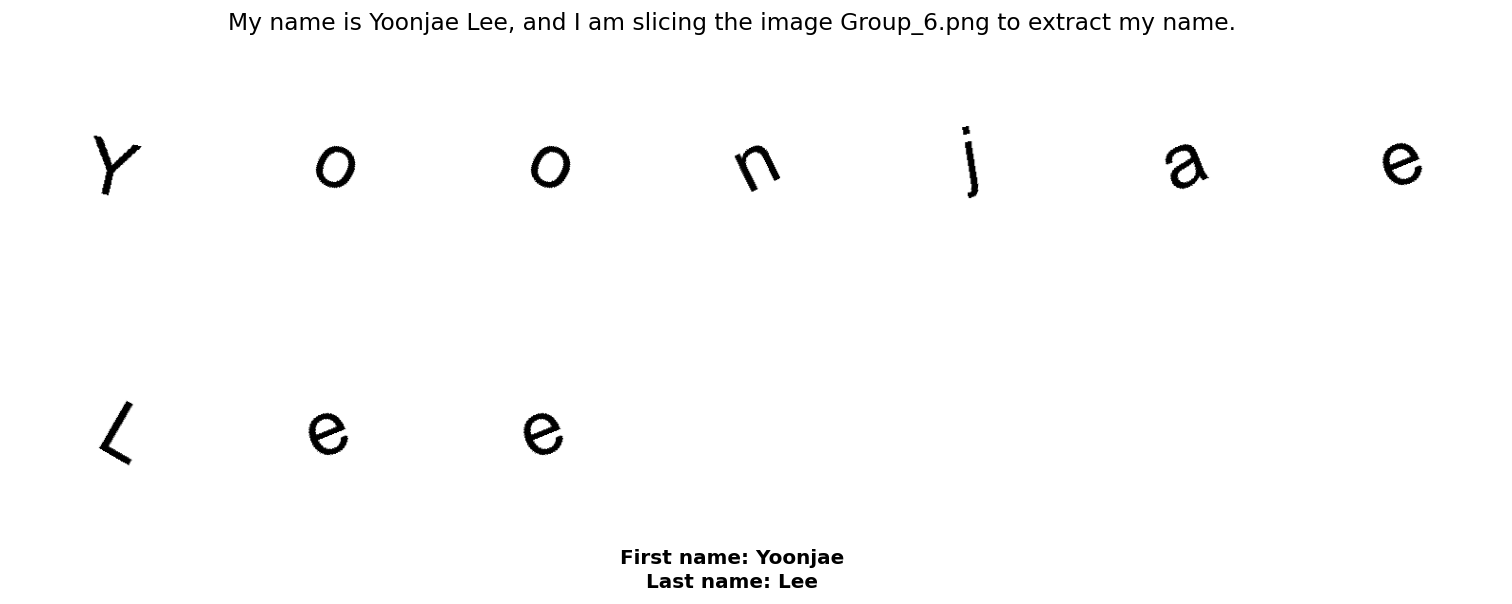

In [5]:
# One figure: first name row, then last name row
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(2, 7, height_ratios=[1, 1], hspace=0.45, top=0.88, bottom=0.12)

fig.suptitle(
    "My name is Yoonjae Lee, and I am slicing the image Group_6.png to extract my name.",
    fontsize=14,
)

for i, patch in enumerate(first_letters):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(np.clip(patch, 0, 255).astype(np.uint8))
    ax.axis("off")

for i, patch in enumerate(last_letters):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(np.clip(patch, 0, 255).astype(np.uint8))
    ax.axis("off")

for j in range(len(last_letters), 7):
    ax = fig.add_subplot(gs[1, j])
    ax.axis("off")

fig.text(0.5, 0.06, "First name: Yoonjae", ha="center", fontsize=12, fontweight="bold")
fig.text(0.5, 0.02, "Last name: Lee", ha="center", fontsize=12, fontweight="bold")

plt.subplots_adjust(wspace=0.08)
plt.show()
